In [169]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [170]:
def bivariate(x, mu, cov, A):
    return np.exp(-(x-mu).T@np.linalg.inv(cov)@(x-mu)/2)*A

def generate_final_height_map(xs,ys, mus, covs, As):

    height = np.zeros((len(xs), len(ys)))

    for mu, cov, A in zip(mus, covs, As):

        h = []
        for x,y in product(xs, ys):
            h.append(bivariate(np.array((x,y)), mu, cov, A))

        h = np.stack(h).reshape(100,100)
        height += h

    return height.T

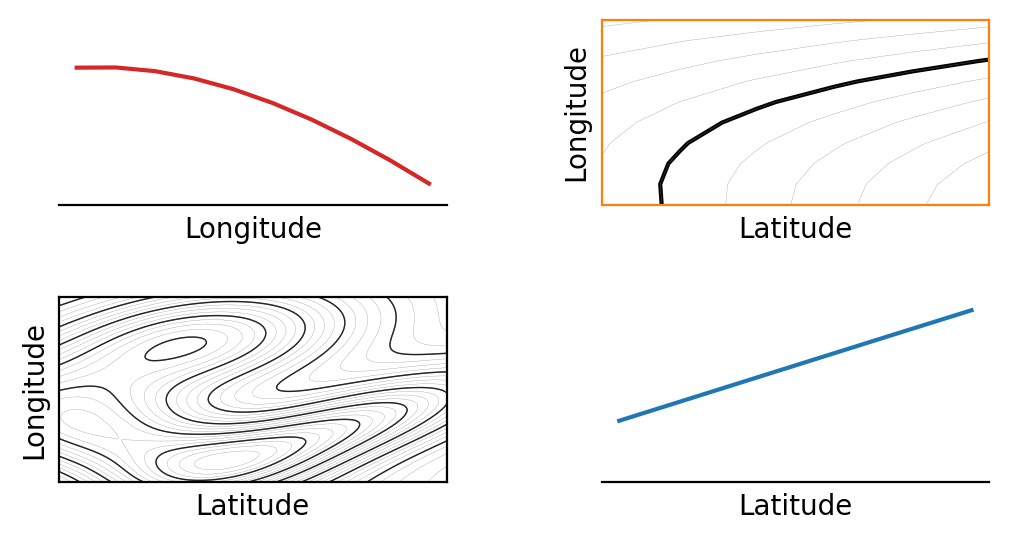

In [171]:
mus = (
    np.array((1,3)),
    np.array((2,1)),
    np.array((.3,1)),
)

covs = (
    np.array(((.8,0.3),(0.3,.8))),
    np.array(((1.,.8),(.8,1))),
    np.array(((1,-.5),(-.5,1.))),
)

As = (
    1.,
    1.,
    1.,
)


xs = np.linspace(0,3, 100)
ys = np.linspace(0,4, 100)

x = 25
y = 15

z = generate_final_height_map(xs, ys, mus, covs, As)


fig, axs = plt.subplots(2,2, figsize=(6,3), dpi=200)
fig.subplots_adjust(wspace=0.4, hspace=0.5)

ax = axs[1,0]
ax.contour(z, linewidths=.5, colors='black')
ax.contour(z, levels=30, linewidths=.1, colors='gray')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

ax = axs[1,1]
ax.plot(z[y,24:30])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latitude')
ax.set_ylim(1.14, 1.24)
# ax.set_ylabel('Altitude')

ax = axs[0,0]
ax.plot(z[10:20,x], color='tab:red')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Longitude')
ax.set_ylim(1.13, 1.23)
# ax.set_ylabel('Altitude')

for ax in (axs[0,0], axs[1,1]):
    for k, v in ax.spines.items():
        if k != 'bottom': v.set_visible(False)

# axs[0,1].axvline(x=x, color='tab:red')
# axs[0,1].axhline(y=y)

ax = axs[0,1]
ax.contour(z[10:20,24:30], colors='black', levels=1)
ax.contour(z[10:20,24:30], colors='gray', linewidths=0.1, levels=10)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
for s in ax.spines.values():
    s.set_edgecolor('tab:orange')

[]

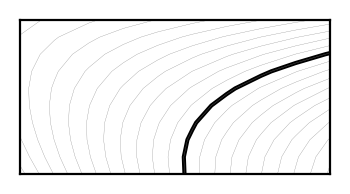

In [172]:
fig, ax = plt.subplots(1,1, figsize=(2,1), dpi=200)

ax.contour(z[10:20,20:30], colors='black', levels=1)
ax.contour(z[10:20,20:30], colors='gray', linewidths=0.1, levels=20)

ax.set_xticks([])
ax.set_yticks([])

[]

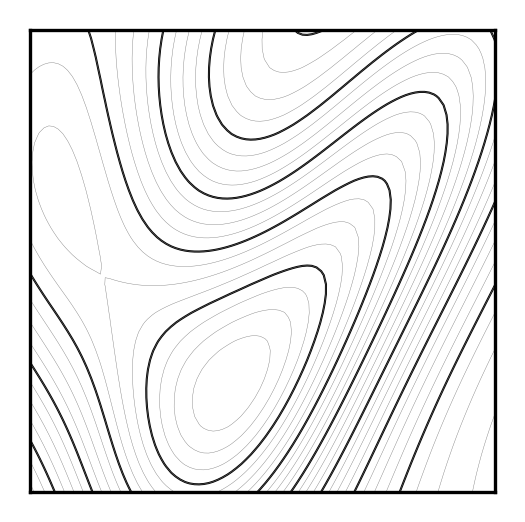

In [173]:
ax = plt.figure(figsize=(2,2,), dpi=300).add_subplot()

ax.contour(z[:50], linewidths=.5, colors='black')
ax.contour(z[:50], levels=30, linewidths=.1, colors='gray')

ax.set_xticks([])
ax.set_yticks([])


In [174]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [175]:
X = np.random.rand(20)*10
Y = 0.5 * X + np.random.randn(20) + 2

In [176]:
X_train, X_val = X[:12], X[12:]
Y_train, Y_val = Y[:12], Y[12:]


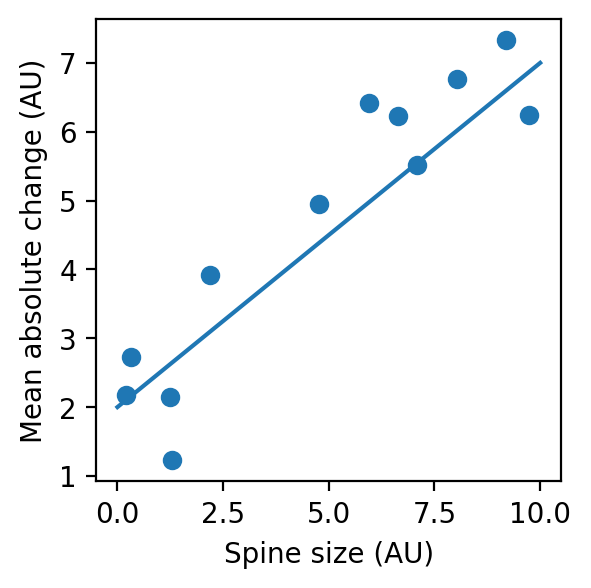

In [177]:
fig, ax = plt.subplots(figsize=(3,3), dpi=200)
ax.scatter(X_train,Y_train)
ax.set_xlabel('Spine size (AU)')
ax.set_ylabel('Mean absolute change (AU)')

x = np.linspace(0,10,100)
ax.plot(x, 2 + 0.5 * x)

Text(0, 0.5, 'Mean absolute change (AU)')

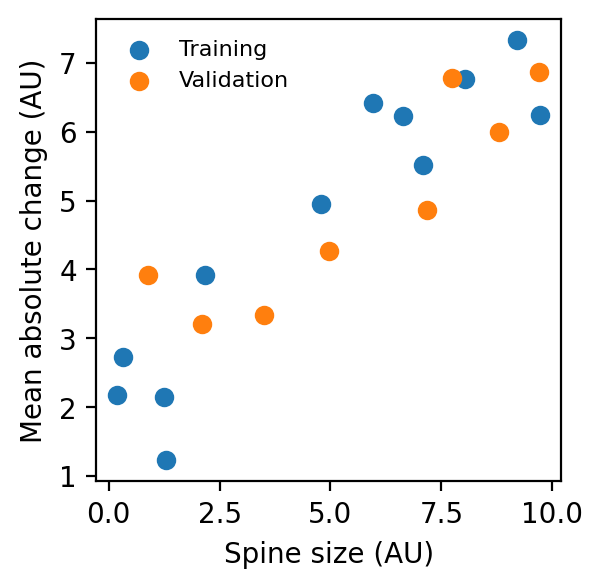

In [178]:
fig, ax = plt.subplots(figsize=(3,3), dpi=200)
ax.scatter(X_train,Y_train, label='Training')
ax.scatter(X_val,Y_val, label='Validation')
ax.legend(frameon=False, fontsize=8)
ax.set_xlabel('Spine size (AU)')
ax.set_ylabel('Mean absolute change (AU)')

Text(0, 0.5, 'Mean absolute change (AU)')

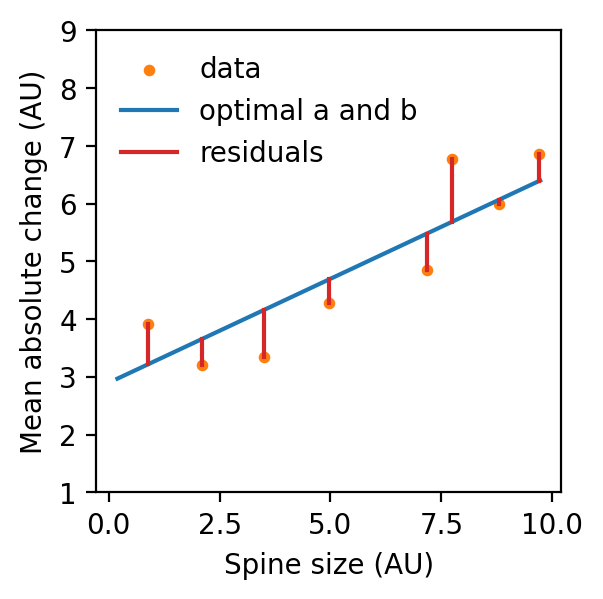

In [179]:
line_X = np.array([X.min(), X.max()])
line_Y = 2.9 + 0.36*line_X

fig, ax = plt.subplots(figsize=(3,3), dpi=200)
ax.scatter(X_val,Y_val, s=10, label='data', c='tab:orange')
ax.plot(line_X, line_Y, label=r'optimal a and b')

check = 1
for x,y in zip(X_val,Y_val):
    if check:
        ax.plot((x,x),(y, x*0.36 + 2.9), label='residuals', c='tab:red')
        check = 0
    else:
        ax.plot((x,x),(y, x*0.36 + 2.9), c='tab:red')

ax.set_ylim(1,9)
ax.legend(frameon=False, loc='upper left')
ax.set_xlabel('Spine size (AU)')
ax.set_ylabel('Mean absolute change (AU)')

In [180]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=True)
pf = poly_features.fit_transform(X_train.reshape(-1,1))

model.fit(pf, Y_train)

pred_train = model.predict(pf)

0.4528715035563062


Text(0, 0.5, 'Mean absolute change (AU)')

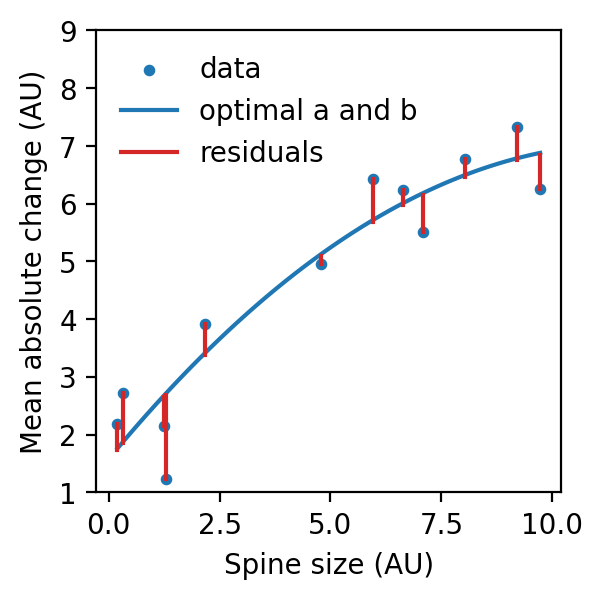

In [181]:
XX = X_train
YY = Y_train

fig, ax = plt.subplots(figsize=(3,3), dpi=200)
ax.scatter(XX,YY, s=10, label='data')

X_plot = np.linspace(XX.min(),XX.max(),100)
Y_plot = model.predict(poly_features.fit_transform(X_plot.reshape(-1,1)))
ax.plot(X_plot, Y_plot, label=r'optimal a and b')

check = 1
mse = 0

for x,y in zip(XX,YY):
    pred_y = 1.55
    for n, c in enumerate(model.coef_):
        pred_y += c * x**n

    mse += (y-pred_y)**2

    if check:
        ax.plot((x,x),(y, pred_y), label='residuals', c='tab:red')
        check = 0
    else:
        ax.plot((x,x),(y, pred_y), c='tab:red')

mse /= len(XX)
print(mse)

ax.set_ylim(1,9)
ax.legend(frameon=False, loc='upper left')
ax.set_xlabel('Spine size (AU)')
ax.set_ylabel('Mean absolute change (AU)')

1.2701486010724932


Text(0, 0.5, 'Mean absolute change (AU)')

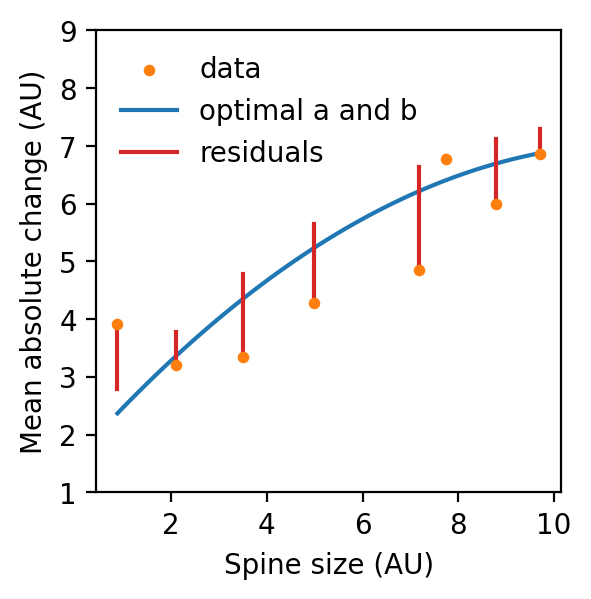

In [182]:
XX = X_val
YY = Y_val

fig, ax = plt.subplots(figsize=(3,3), dpi=200)
ax.scatter(XX,YY, s=10, label='data', c='tab:orange', zorder=10)

X_plot = np.linspace(XX.min(),XX.max(),100)
Y_plot = model.predict(poly_features.fit_transform(X_plot.reshape(-1,1)))
ax.plot(X_plot, Y_plot, label=r'optimal a and b')

check = 1
mse = 0

for x,y in zip(XX,YY):
    pred_y = 2
    for n, c in enumerate(model.coef_):
        pred_y += c * x**n

    mse += (y-pred_y)**2

    if check:
        ax.plot((x,x),(y, pred_y), label='residuals', c='tab:red')
        check = 0
    else:
        ax.plot((x,x),(y, pred_y), c='tab:red')

mse /= len(XX)
print(mse)

ax.set_ylim(1,9)
ax.legend(frameon=False, loc='upper left')
ax.set_xlabel('Spine size (AU)')
ax.set_ylabel('Mean absolute change (AU)')

Text(0, 0.5, 'b')

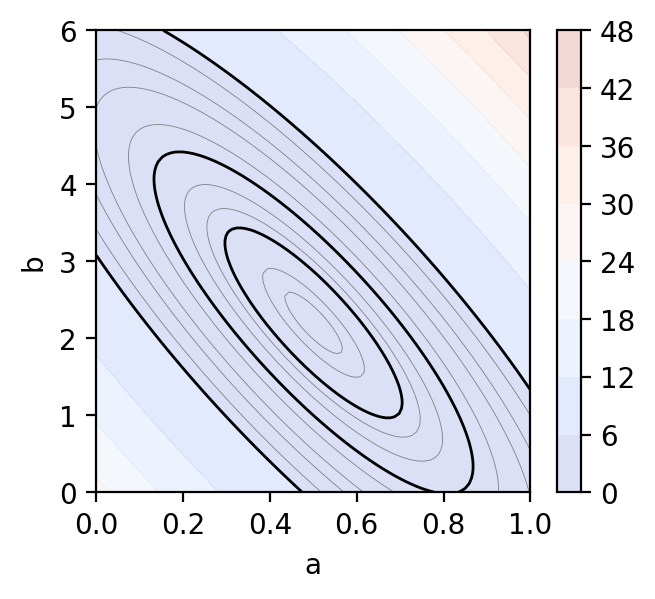

In [183]:
def criterion(a,b, X, Y):

    crit = 0

    for x, y in zip(X,Y):
        crit += (y - a*x - b)**2

    crit /= len(X)

    return crit


aa = np.linspace(0,1,100)
bb = np.linspace(0,6,100)

ga, gb = np.meshgrid(aa,bb)

z = []

for a, b in product(aa, bb):
    z.append(criterion(a,b, X, Y))

z = np.array(z).reshape(len(aa), len(bb)).T

fig, ax = plt.subplots(figsize=(3.5,3), dpi=200)
c = ax.contourf(ga, gb, z, alpha=0.2, cmap='coolwarm')
ax.contour(ga, gb, z, levels=(0.1, 1, 2, 6), colors='black', linewidths=1)
ax.contour(ga, gb, z, levels=(0.5, 0.6, 0.7, 1.2, 1.5,  2.5, 3.3, 4,5), colors='gray', linewidths=0.3)
plt.colorbar(c)

ax.set_xlabel('a')
ax.set_ylabel('b')

# ax.legend(frameon=False, loc='upper left')
# ax.set_xlabel('Spine size (AU)')
# ax.set_ylabel('Mean absolute change (AU)')

[]

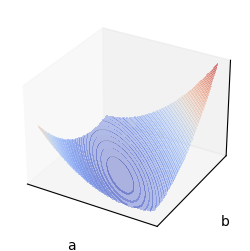

In [240]:
ax = plt.figure(figsize=(3,3), dpi=100).add_subplot(projection='3d')
# plt.subplots_adjust(right=1)

ax.contourf(aa,bb,z, levels=100, cmap='coolwarm', alpha=0.4)
ax.contour(aa,bb,z, levels=50, colors='black', linewidths=0.1)
ax.set_xlabel('a', labelpad=0)
ax.set_ylabel('b', labelpad=0)
ax.set_zlabel('MSE', labelpad=0)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

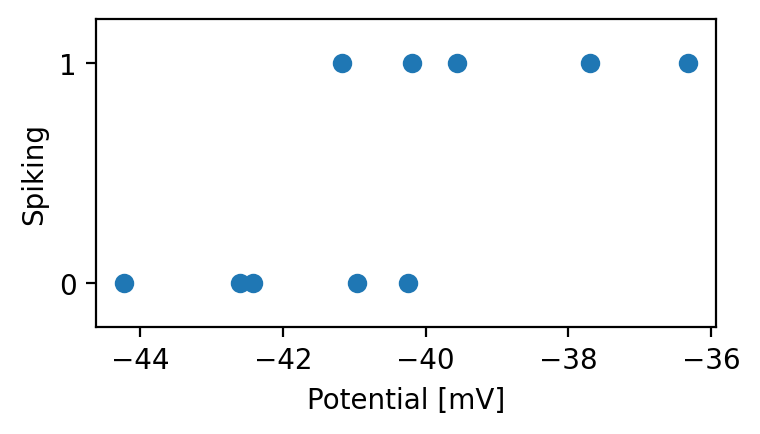

In [156]:
X = np.random.rand(10)

Y = []
sigma = 0.5

for x in X:
    Y.append((np.random.rand()-0.5)*0.7 + 0.5 < x)

X = (X-0.5)*10 - 40


fig, ax = plt.subplots(figsize=(4,2), dpi=200)
ax.scatter(X,Y)

ax.set_yticks([0,1])
ax.set_xlabel('Potential [mV]')
ax.set_ylabel('Spiking')
ax.set_ymargin(0.2)


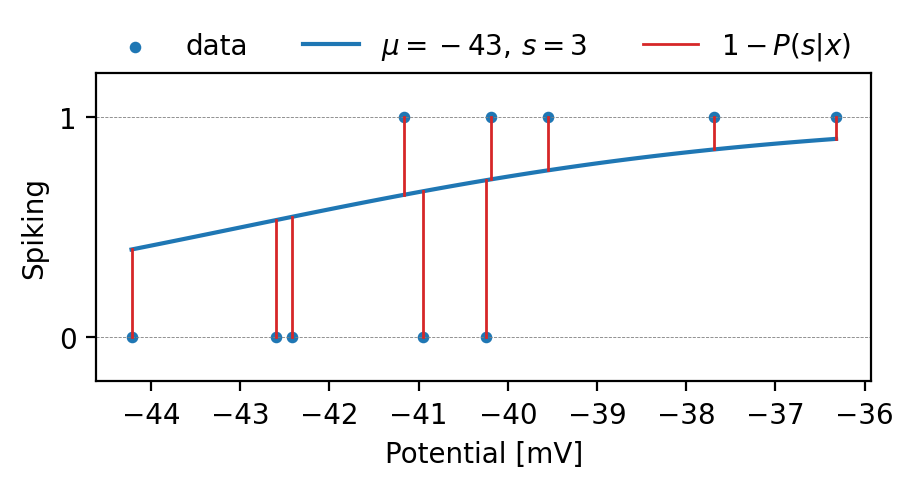

In [157]:
def logistic(x,mu,sigma):
    return 1/(1 + np.exp(-(x - mu)/sigma))

def criterion(mu,sigma):
    crit = 0
    for x, y in zip(X,Y):
        if y: crit -= np.log(logistic(x,mu,sigma))
        else: crit -= np.log(1-logistic(x,mu,sigma))

    return crit

mu = -43
s = 3

line_X = np.linspace(X.min(), X.max(), 100)


fig, ax = plt.subplots(figsize=(5,2), dpi=200)
ax.scatter(X,Y, s=10, label='data')
ax.plot(line_X, logistic(line_X, mu,s), label=r'$\mu=-43, \, s=3$')
ax.axhline(y=1, linestyle='--', linewidth=0.3, c='gray')
ax.axhline(y=0, linestyle='--', linewidth=0.3, c='gray')

check = 1
for x,y in zip(X,Y):
    if check:
        ax.plot((x,x), (y, logistic(x,mu,s)), c='tab:red', linewidth=1, label=r'$1 - P(s|x)$')
        check=0
    else:
        ax.plot((x,x), (y, logistic(x,mu,s)), c='tab:red', linewidth=1)

ax.legend(frameon=False, ncols=3, loc=(0,1))
ax.set_yticks([0,1])
ax.set_xlabel('Potential [mV]')
ax.set_ylabel('Spiking')
ax.set_ymargin(0.2)
# ax.set_ylim(-0.2, 1.5)

Text(0, 0.5, '$s$')

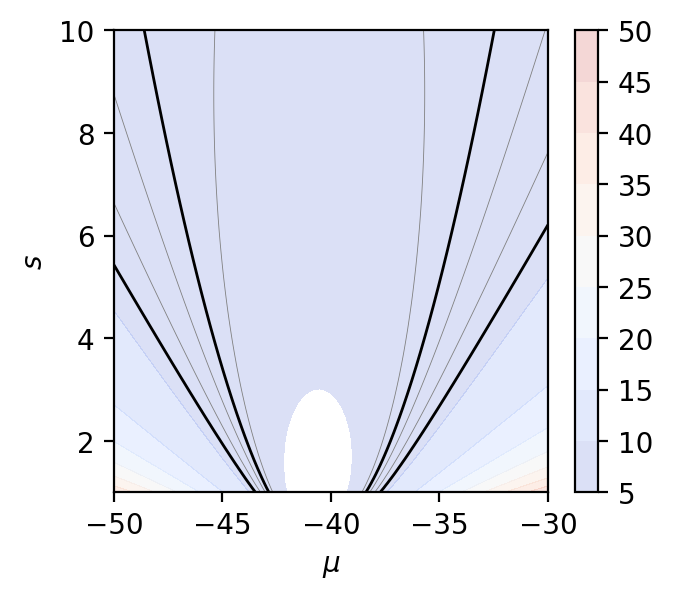

In [158]:
mus = np.linspace(-50,-30,100)
sigmas = np.linspace(1,10,100)

gm, gs = np.meshgrid(mus, sigmas)

z = []
for mu, sigma in product(mus, sigmas):
    z.append(criterion(mu, sigma))

z = np.array(z).reshape(len(mus,), len(sigmas)).T

fig, ax = plt.subplots(figsize=(3.5,3), dpi=200)
c = ax.contourf(gm, gs, z, alpha=0.2, cmap='coolwarm', levels=(5,10,15,20,25,30,35,40,45,50))
ax.contour(gm, gs, z, levels=(7,9), colors='black', linewidths=1)
ax.contour(gm, gs, z, levels=(6.5,7.5,8.2), colors='gray', linewidths=0.3)
plt.colorbar(c)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$s$')


In [159]:
# Y = np.array(Y)

# model = LogisticRegression(random_state=0)
# result = model.fit(X.reshape(-1,1),Y)



# line_p_hat = model.predict_proba(line_X.reshape(-1,1))[:,1]
# p_hat = model.predict_proba(X.reshape(-1,1))[:,1]

# fig, ax = plt.subplots(figsize=(5,2), dpi=200)
# ax.scatter(X,Y, s=10, label='data')
# ax.plot(line_X, line_p_hat, label=r'$\mu=-38.9, \, s=1.3$')
# ax.axhline(y=1, linestyle='--', linewidth=0.3, c='gray')
# ax.axhline(y=0, linestyle='--', linewidth=0.3, c='gray')

# check = 1
# for x,y, p in zip(X,Y, p_hat):
#     if check:
#         ax.plot((x,x), (y, p), c='tab:red', linewidth=1, label=r'$1 - P(s|x)$')
#         check=0
#     else:
#         ax.plot((x,x), (y, p), c='tab:red', linewidth=1)

# ax.legend(frameon=False, ncols=3, loc=(-0.04,1))
# ax.set_yticks([0,1])
# ax.set_xlabel('Potential [mV]')
# ax.set_ylabel('Spiking')
# ax.set_ymargin(0.2)

In [160]:
x = np.random.randn(10)*0.1
W = np.random.randn(10,10)*2

t = np.linspace(0,20,200)
Y = np.sin(t)

X = [x]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

for y in Y:
    X.append(sigmoid(W@X[-1].T + np.random.randn(10)*1 + y))

X = np.array(X[1:])

Text(0.5, 0, 'Time [s]')

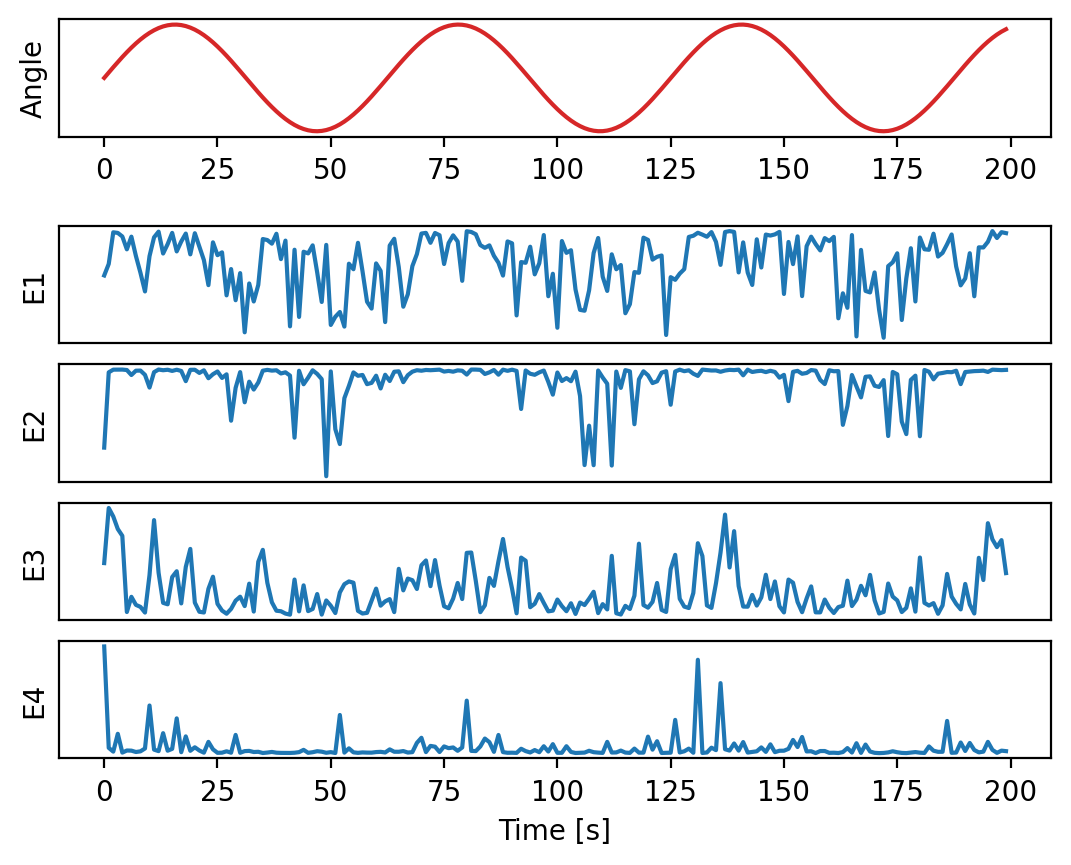

In [161]:
fig, axs = plt.subplots(6,1, height_ratios=(1,0.4,1,1,1,1), dpi=200)
axs[1].remove()

ax = axs[0]
ax.plot(Y, c='tab:red')
ax.set_yticks([])
ax.set_ylabel('Angle')

axs[5].plot(X[:,2])
axs[2].plot(X[:,6])
axs[3].plot(X[:,7])
axs[4].plot(X[:,8])

for i, ax in enumerate(axs[1:]):
    ax.set_yticks([])
    ax.set_ylabel(f'E{i}')

for ax in axs[1:-1]: ax.set_xticks([])

axs[-1].set_xlabel('Time [s]')

In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X_train, X_val, Y_train, Y_val = train_test_split(X,Y, shuffle=False)

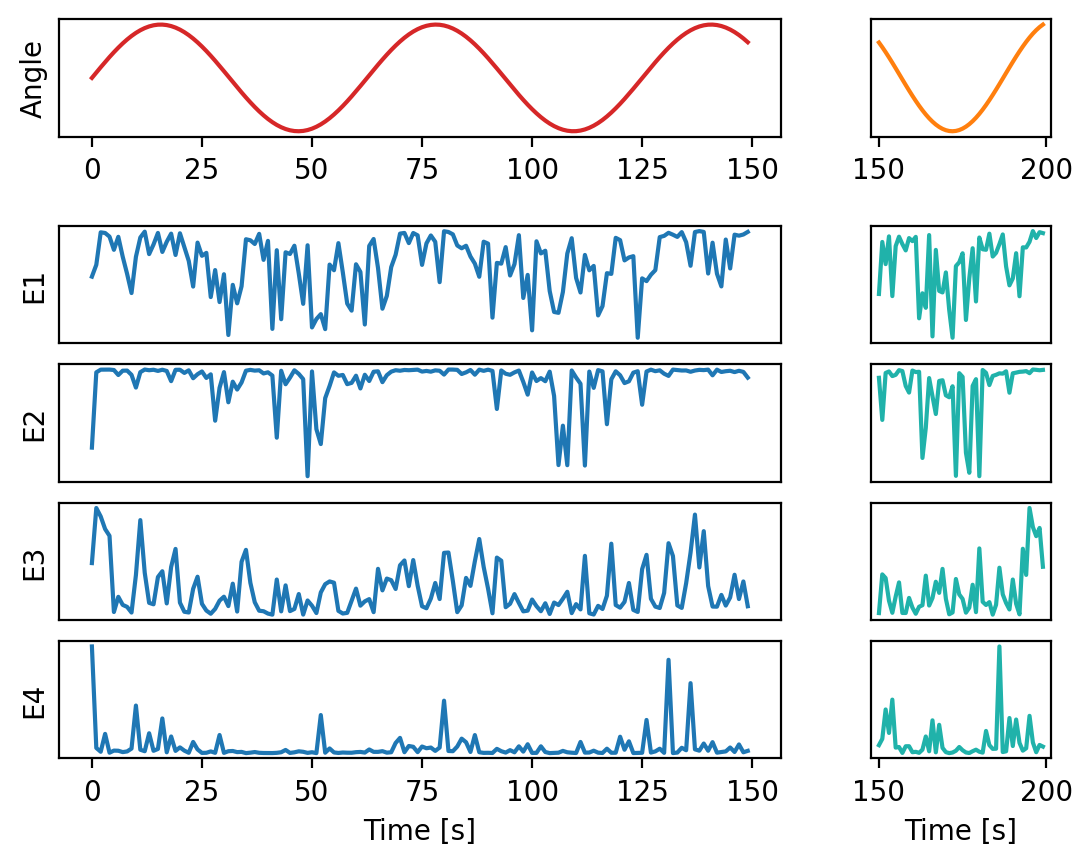

In [164]:
fig, axs = plt.subplots(6,2, height_ratios=(1,0.4,1,1,1,1), width_ratios=(0.8,0.2), dpi=200)
axs[1,0].remove()
axs[1,1].remove()

col = axs[:,0]

ax = col[0]
ax.plot(Y_train, c='tab:red')
ax.set_yticks([])
ax.set_ylabel('Angle')


col[5].plot(X_train[:,2])
col[2].plot(X_train[:,6])
col[3].plot(X_train[:,7])
col[4].plot(X_train[:,8])

for i, ax in enumerate(col[1:]):
    ax.set_yticks([])
    ax.set_ylabel(f'E{i}')

for ax in col[1:-1]: ax.set_xticks([])


col[-1].set_xlabel('Time [s]')

col = axs[:,1]
ax = col[0]
ax.plot(Y_val, c='tab:orange')
ax.set_yticks([])
ax.set_xticks([0,50], ['150','200'])

col[5].plot(X_val[:,2], c='lightseagreen')
col[2].plot(X_val[:,6], c='lightseagreen')
col[3].plot(X_val[:,7], c='lightseagreen')
col[4].plot(X_val[:,8], c='lightseagreen')

for i, ax in enumerate(col[1:]):
    ax.set_yticks([])

for ax in col[1:-1]: ax.set_xticks([])

col[-1].set_xlabel('Time [s]')

col[-1].set_xticks([0,50],[150,200]);

Text(0.5, 0, 'Time [s]')

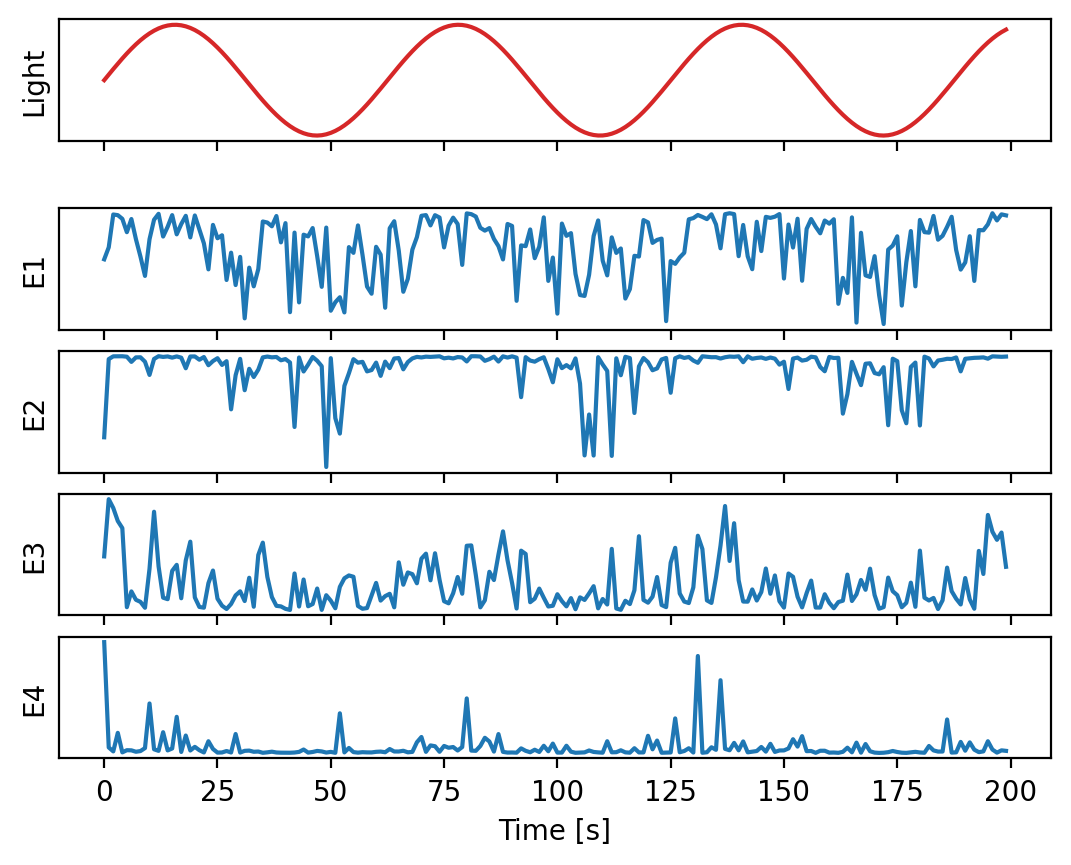

In [165]:
fig, axs = plt.subplots(6,1, sharex=True, height_ratios=(1,0.2,1,1,1,1), dpi=200)
axs[1].remove()

ax = axs[0]
ax.plot(Y, c='tab:red')
ax.set_yticks([])
ax.set_ylabel('Light')

axs[5].plot(X[:,2])
axs[2].plot(X[:,6])
axs[3].plot(X[:,7])
axs[4].plot(X[:,8])

for i, ax in enumerate(axs[1:]):
    ax.set_yticks([])
    ax.set_ylabel(f'E{i}')


axs[-1].set_xlabel('Time [s]')

In [166]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=(2000), activation='relu')


model.fit(X_train,Y_train)

/home/janko/.virtualenvs/base/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=2000)

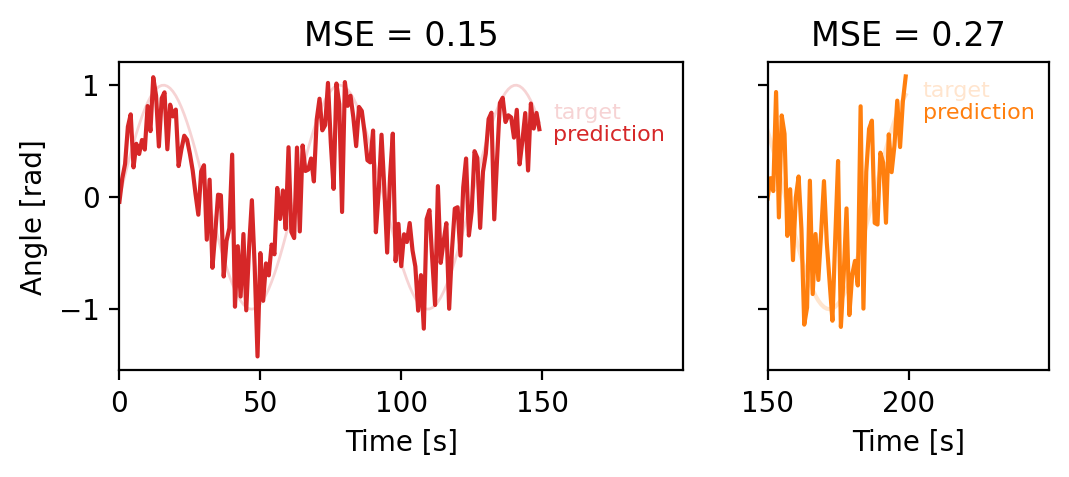

In [167]:
prediction_train = model.predict(X_train)
prediction_val = model.predict(X_val)

mse_train = ((prediction_train - Y_train)**2).mean()
mse_val = ((prediction_val - Y_val)**2).mean()

fig, axs = plt.subplots(1,2,width_ratios=(2,1), figsize=(6,2), dpi=200, sharey=True)

ax = axs[0]
ax.plot(Y_train, c='tab:red', alpha=0.2, linewidth=1)
ax.plot(prediction_train, c='tab:red')

ax.set_xlim(0,200)
ax.text(154, 0.7, 'target', c='tab:red', alpha=0.2, fontsize=8 )
ax.text(154, 0.5, 'prediction', c='tab:red', fontsize=8 )

ax.set_xticks([0,50,100,150])

ax.set_title(f'MSE = {mse_train:.2f}')
ax.set_ylabel('Angle [rad]')
ax.set_xlabel('Time [s]')

ax = axs[1]
ax.plot(Y_val, c='tab:orange', alpha=0.2)
ax.plot(prediction_val, c='tab:orange')

ax.set_xlim(0,100)
ax.text(55, 0.9, 'target', c='tab:orange', alpha=0.2, fontsize=8 )
ax.text(55, 0.7, 'prediction', c='tab:orange', fontsize=8 )

ax.set_title(f'MSE = {mse_val:.2f}')
ax.set_xlabel('Time [s]')
ax.set_xticks([0,50],[150,200])

In [168]:
# 1. Get the data
X_train, Y_train, X_test = # get some data #

# 2. Split into training and validation
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train)

# 3. Select the model (and loss function)
model = Perceptron(loss='squared_error')

# 4. Fit the model
model.fit(X_train, Y_train)

# 5. Evaluate on validation
prediction_val = model.predict(X_val)
# --- evaluation --- #

# 6. Finally: predict the testing 
prediction_test = model.predict(X_test)

# Good luck!

SyntaxError: invalid syntax (1835345469.py, line 2)